<a href="https://colab.research.google.com/github/RiteeshTM/Financial-Market-Trend-Risk-Analysis-Business-Analytics-Project-/blob/main/BusinessAnalyticsProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA

In [ ]:
data = yf.download("RELIANCE.NS", start="2018-01-01")

if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)

data.tail()

/tmp/ipykernel_5548/941683073.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("RELIANCE.NS", start="2018-01-01")
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Date,,,,,
2026-02-27,1393.900024,1410.400024,1388.099976,1398.000000,12031440
2026-03-02,1358.000000,1378.599976,1341.500000,1375.500000,23728722
2026-03-04,1345.000000,1352.800049,1307.000000,1330.000000,32495007
2026-03-05,1389.400024,1399.000000,1353.099976,1353.099976,25957532
2026-03-06,1404.800049,1424.300049,1390.300049,1396.500000,19311019


In [ ]:
data["simple_return"] = data["Close"].pct_change()

data["log_return"] = np.log(data["Close"] / data["Close"].shift(1))

data = data.dropna()
data

Price,Close,High,Low,Open,Volume,simple_return,log_return
Date,,,,,,,
2018-01-02,402.483215,406.193768,400.384994,403.300424,9499419,0.001539,0.001538
2018-01-03,404.095520,409.042914,403.322483,408.601166,13507800,0.004006,0.003998
2018-01-04,406.525055,407.187662,404.493091,405.575331,9008932,0.006012,0.005994
2018-01-05,407.828186,409.440517,406.503001,407.187694,7441284,0.003206,0.003200
2018-01-08,410.169373,411.251612,407.938635,409.087133,8827020,0.005741,0.005724
...,...,...,...,...,...,...,...
2026-02-27,1393.900024,1410.400024,1388.099976,1398.000000,12031440,-0.009170,-0.009212
2026-03-02,1358.000000,1378.599976,1341.500000,1375.500000,23728722,-0.025755,-0.026093
2026-03-04,1345.000000,1352.800049,1307.000000,1330.000000,32495007,-0.009573,-0.009619


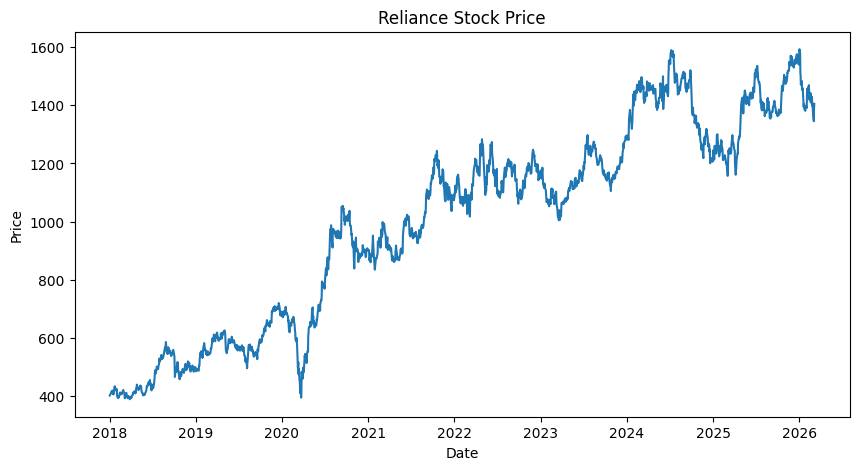

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(data.index, data["Close"])
plt.title("Reliance Stock Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

## Volatility Analysis

In [ ]:
daily_volatility = data["log_return"].std()
annual_volatility = daily_volatility * np.sqrt(252)

print("Daily Volatility:", daily_volatility)
print("Annual Volatility:", annual_volatility)

Daily Volatility: 0.017498574242563406
Annual Volatility: 0.27778125446413926


## Sharpe Ratio

In [ ]:
annual_return = data["log_return"].mean() * 252

risk_free_rate = 0.07  # Approx Indian risk-free rate

sharpe_ratio = (annual_return - risk_free_rate) / annual_volatility

print("Annual Return:", annual_return)
print("Sharpe Ratio:", sharpe_ratio)

Annual Return: 0.15613202053448302
Sharpe Ratio: 0.310071393048599


## Beta Calculation (Market Risk)

In [ ]:
# Download NIFTY data
market = yf.download("^NSEI", start="2018-01-01")

if isinstance(market.columns, pd.MultiIndex):
    market.columns = market.columns.get_level_values(0)

data.index = data.index.tz_localize(None)
market.index = market.index.tz_localize(None)

market["market_return"] = np.log(
    market["Close"] / market["Close"].shift(1)
)

df = pd.concat(
    [data["log_return"], market["market_return"]],
    axis=1
).dropna()

# Regression
X = sm.add_constant(df["market_return"])
y = df["log_return"]

model = sm.OLS(y, X).fit()

beta = model.params[1]

print("Beta:", beta)

/tmp/ipykernel_651/2706225358.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  market = yf.download("^NSEI", start="2018-01-01")
[*********************100%***********************]  1 of 1 completed

Beta: 1.1157036614712421



/tmp/ipykernel_651/2706225358.py:25: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  beta = model.params[1]


##  Value at Risk (VaR)

In [ ]:
VaR_95 = np.percentile(data["log_return"], 5)

print("95% Value at Risk:", VaR_95)

95% Value at Risk: -0.023577139390673782


## Stationarity Test (ADF)

In [ ]:
result = adfuller(data["log_return"])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -13.475951827318017
p-value: 3.3119587956842406e-25


## ARIMA Model

In [ ]:
model = ARIMA(data["log_return"], order=(1,0,1))
model_fit = model.fit()

print(model_fit.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:             log_return   No. Observations:                 2020
Model:                 ARIMA(1, 0, 1)   Log Likelihood                5307.179
Date:                Fri, 06 Mar 2026   AIC                         -10606.359
Time:                        18:19:47   BIC                         -10583.915
Sample:                             0   HQIC                        -10598.122
                               - 2020                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0006      0.000      1.577      0.115      -0.000       0.001
ar.L1         -0.6060      0.280     -2.167      0.030      -1.154      -0.058
ma.L1          0.5841      0.284      2.057      0.0

## Forecast Future Returns

In [ ]:
forecast = model_fit.forecast(steps=5)

print("Next 5 day forecast:")
print(forecast)

Next 5 day forecast:
2020    0.000813
2021    0.000499
2022    0.000689
2023    0.000574
2024    0.000644
Name: predicted_mean, dtype: float64


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


## Return Distribution

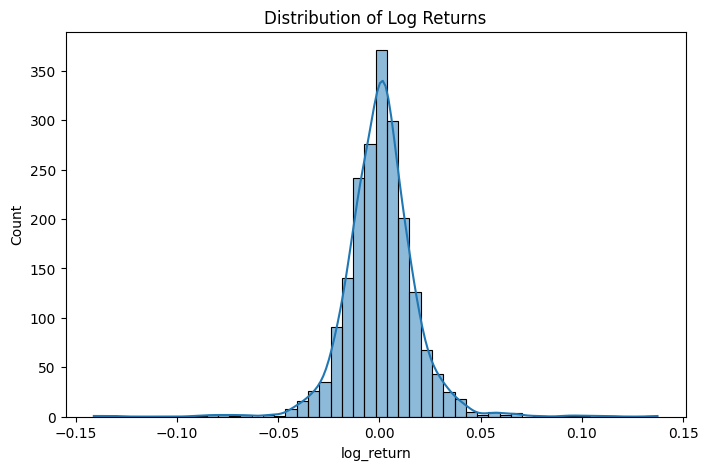

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(data["log_return"], bins=50, kde=True)
plt.title("Distribution of Log Returns")
plt.show()

## Performance Analysis using Pyfolio

In this section we analyze the performance of Reliance Industries stock using the Pyfolio library.

We compare the performance of Reliance Industries against the NIFTY 50 index.

In [ ]:
!pip install pyfolio-reloaded

In [ ]:
import pyfolio as pf
import pandas as pd
import numpy as np
import yfinance as yf

/usr/local/lib/python3.12/dist-packages/pyfolio/pos.py:25: UserWarning: Module "zipline.assets" not found; multipliers will not be applied to position notionals.
  warnings.warn(


### Download Benchmark Data (NIFTY 50)

To evaluate the performance of the stock relative to the market, we use the NIFTY 50 index as a benchmark.

In [ ]:
market = yf.download("^NSEI", start="2018-01-01")

# fix multiindex if present
if isinstance(market.columns, pd.MultiIndex):
    market.columns = market.columns.get_level_values(0)

market.tail()

/tmp/ipykernel_5548/1969775549.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  market = yf.download("^NSEI", start="2018-01-01")
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Date,,,,,
2026-02-27,25178.650391,25476.400391,25141.300781,25459.849609,438900
2026-03-02,24865.699219,24989.349609,24603.500000,24659.250000,519200
2026-03-04,24480.500000,24602.449219,24305.400391,24388.800781,599000
2026-03-05,24765.900391,24854.199219,24529.400391,24615.949219,504300
2026-03-06,24450.449219,24700.900391,24415.750000,24656.400391,0


### Compute Benchmark Returns

We compute log returns for the benchmark index to ensure consistency with the stock returns used earlier.

In [ ]:
market["market_return"] = np.log(
    market["Close"] / market["Close"].shift(1)
)

benchmark_returns = market["market_return"].dropna()

benchmark_returns.head()

,market_return
Date,
2018-01-03,0.000096
2018-01-04,0.005881
2018-01-05,0.005132
2018-01-08,0.006114
2018-01-09,0.001261


### Prepare Stock Returns

Pyfolio requires a clean return series indexed by datetime.

We remove timezone information and ensure the data is aligned properly.

In [ ]:
returns = data["log_return"]

# remove timezone if present
returns.index = returns.index.tz_localize(None)
benchmark_returns.index = benchmark_returns.index.tz_localize(None)

### Generate Pyfolio Performance Report

The Pyfolio tear sheet provides a comprehensive summary of portfolio performance including:

- cumulative returns
- drawdown periods
- rolling Sharpe ratio
- volatility analysis
- return distribution

/usr/local/lib/python3.12/dist-packages/pyfolio/plotting.py:670: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '12.413%' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  perf_stats.loc[stat, column] = str(np.round(value * 100, 3)) + "%"


Start date,2018-01-03
End date,2026-03-06
Total months,95
,Backtest
Annual return,12.413%
Cumulative returns,154.885%
Annual volatility,27.812%
Sharpe ratio,0.56
Calmar ratio,0.26
Stability,0.82
Max drawdown,-47.467%


Worst drawdown periods,Net drawdown in %,Peak date,Valley date,Recovery date,Duration
0,47.47,2019-12-19,2020-03-23,2020-06-19,132
1,28.12,2024-07-08,2025-03-04,NaT,NaN
2,23.70,2022-04-28,2023-03-20,2024-01-11,446
3,22.80,2018-08-28,2018-10-25,2019-03-19,146
4,22.37,2020-09-16,2021-01-29,2021-09-06,254


/usr/local/lib/python3.12/dist-packages/pyfolio/plotting.py:1407: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Daily", "Weekly", "Monthly"])


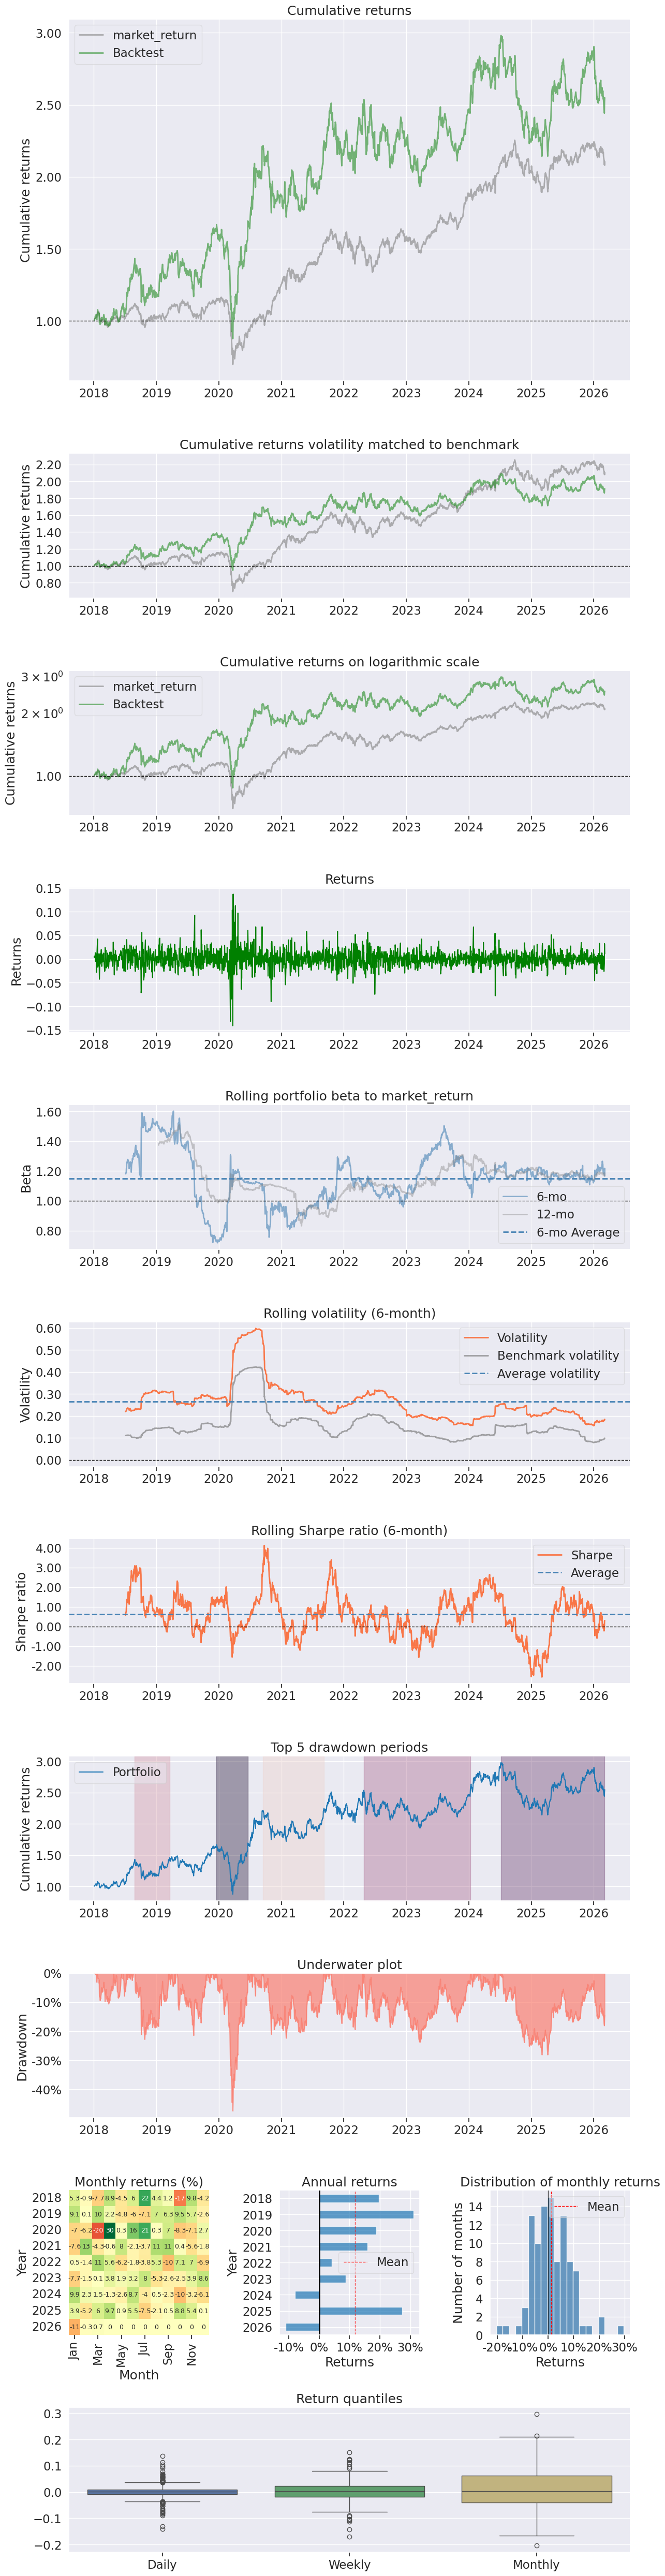

In [ ]:
pf.create_returns_tear_sheet(
    returns,
    benchmark_rets=benchmark_returns
)

### Rolling Volatility

Rolling volatility helps visualize how risk evolves over time.

<Axes: title={'center': 'Rolling volatility (6-month)'}, ylabel='Volatility'>

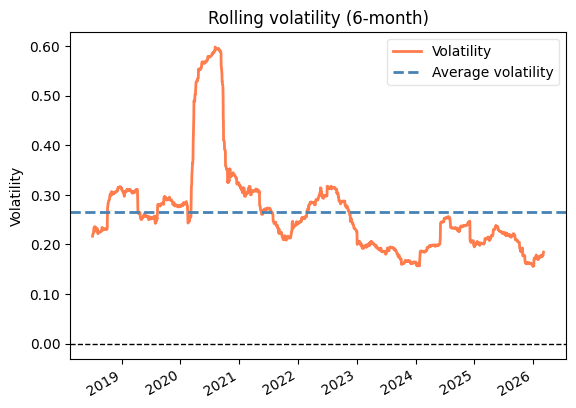

In [ ]:
pf.plotting.plot_rolling_volatility(returns)

### Rolling Sharpe Ratio

This plot shows how the risk-adjusted return changes through time.

<Axes: title={'center': 'Rolling Sharpe ratio (6-month)'}, ylabel='Sharpe ratio'>

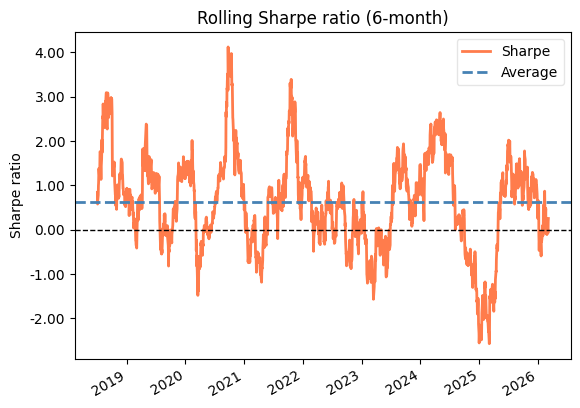

In [ ]:
pf.plotting.plot_rolling_sharpe(returns)

### Drawdown Analysis

Drawdown represents the decline from a historical peak.

This helps identify periods of large losses.

<Axes: title={'center': 'Top 10 drawdown periods'}, ylabel='Cumulative returns'>

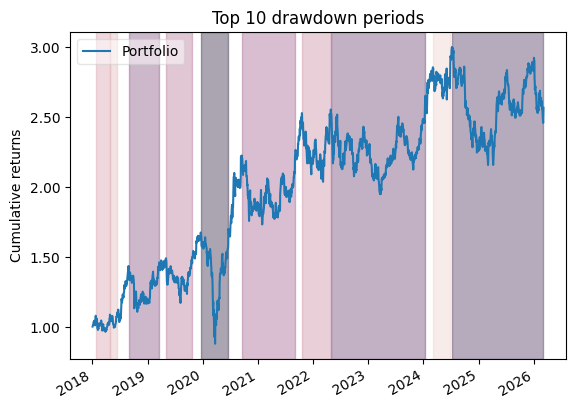

In [ ]:
pf.plotting.plot_drawdown_periods(returns)

Final cell for riteesh

starting cell for nehan

finalcell for nehan

starting cell for girish

final cell for girish

start prakyath

end prakyath

start nikshith

end nikshith